# Homework 5

The purpose of this homework is to advance your final project in a structured way in order to get feedback from the teaching team early. 

For this homework you have three main goals: 
* Build out the motivation for your study
* Refine your research question
* Collect and clean all of your data

There will be **two deliverables that you will upload to Canvas**: 
1. A powerpoint presentation draft of the motivation and research question. 
2. This .ipynb of any necessary data collecting and cleaning

By the end of this homework assignment, you should have a clear story of why you are pursuing this question, what the question is, and fully cleaned data ready for analysis.

## Instructions for the Powerpoint

### Motivation section

Build a draft of the opening slides of your final presentation. These should cover: 
* The big picture problem you are trying to solve and why its important (This is very important!)
* What we know now about the question and what open questions remain (Convince us that this hasn't been done yet)
* The real world context of your study (Nobody else in the room knows the context of your study as well as you!)
* Your research question 

Tips for effective slides:
- **Minimize use of text**. Use text to enhance your slides, don't rely on it. You should not have paragraphs of text on your slides. Think punchy statements that compliment your voice tract.
- **Use some text**. Conversely, slides that have one big image of a butterfly and no context are not useful. You want your slides to standalone even without you talking. This is a delicate balance!
- **Use color and bolding to emphasize key points**. What are the key phrases we need to remember or focus on? Use text to highlight these phrases.
- **Treat your slides like a story**. This is not a journal article in visual format. This is a sales pitch for why we should care about your research.

There is not a hard and fast limit to the number of slides this should be. However, it should, in minutes, take about 3-4 minutes of a 10 minute talk. Depending on how you like to build slides, the number this works out to be is up to you. 

## Instructions for the .ipynb Code

In the following cells, add code to collect and clean all of the data you need. Remember you need at least two different data sources for the final project. 

If you collect your data from somewhere else, add markdown comments to explain where you got it, and what is represented inside the dataset. If you collect your data through APIs, add the code here. 

For any cleaning steps necessary, investigate the data to see what the columns hold, determine if you need to exclude or modify any rows, and do any merging or joining necessary. You should end up with the final datasets you need in order to run your analysis. Save these cleaned files for later use. 

In every cell block, make sure to add adequate comments such that someone else could run your code and understand the purpose if needed. For longer explanations, use markdown language or full docstring comments. 

In [201]:
import pandas as pd
import geopandas as gpd
import numpy as np 
import statsmodels.formula.api as smf
from us import states
import matplotlib.pyplot as plt
from libpysal import io
from libpysal import weights
import osmnx as ox
from key import CENSUS_KEY
from census import Census
import statsmodels.formula.api as smf
import networkx as nx

In [2]:
c = Census(CENSUS_KEY)

In [3]:
variables = {'B02001_001E': 'Total Population',
    'B19301_001E': 'Per Capita Income',
    'B02001_002E': 'White Population',
    'B17001_001E': 'Population Measured for Poverty Status',
    'B17001_002E': 'People Below Poverty Level',
    'B25003_001E': 'Occupied_units'}

ny_tracts = c.acs5.get(
    list(variables.keys()),
    {'for': 'tract:*', 
     'in': 'state:36 county:061'}, 
    year=2020,
)

## Comment: Need to decide which variables we are gonna add

In [252]:
ny_df = pd.DataFrame(ny_tracts)
ny_df = ny_df.rename(columns=variables)
ny_df['GEOID'] = ny_df['state'] + ny_df['county'] + ny_df['tract']
ny_df["white_share"] = ny_df["White Population"] / ny_df["Total Population"]
ny_df["nonwhite_share"] = 1 - ny_df["white_share"]
ny_df["poverty_rate"] = ny_df["People Below Poverty Level"] / ny_df["Population Measured for Poverty Status"]
ny_df.head()
## Comment:  Rename ACS variable codes into readable names.
## Create a unique `GEOID` for each tract.
## Calculate key percentage variables, such as white share, nonwhite share, and poverty rate.
## Keep the dataframe ready for later merging with tract geometries.

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,white_share,nonwhite_share,poverty_rate
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,0.812856,0.187144,0.094396
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,0.470510,0.529490,0.302620
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,0.864312,0.135688,0.092275
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,0.331663,0.668337,0.433420
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,0.833535,0.166465,0.104807


In [253]:
year = 2020
state_fips = "36"

url = f"https://www2.census.gov/geo/tiger/TIGER{year}/TRACT/tl_{year}_{state_fips}_tract.zip"

tracts = gpd.read_file(url)
tracts = tracts.to_crs(epsg=4326)
tracts.head()

## Comment: Set the year and New York State FIPS code.
## Build the shapefile URL from the Census TIGER/Line website.
## Read the tract geometries into a GeoDataFrame.
## Reproject the data to EPSG:4326.
## Prepare the tract boundary data for later filtering and merging

,STATEFP,COUNTYFP,TRACTCE,GEOID,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,36,047,000700,36047000700,7,Census Tract 7,G5020,S,176774,0,+40.6923505,-073.9973434,"POLYGON ((-74.00154 40.69279, -74.00132 40.693..."
1,36,047,000900,36047000900,9,Census Tract 9,G5020,S,163469,0,+40.6917206,-073.9916018,"POLYGON ((-73.99405 40.6909, -73.99374 40.6915..."
2,36,047,001100,36047001100,11,Census Tract 11,G5020,S,168507,0,+40.6932903,-073.9877087,"POLYGON ((-73.99073 40.69305, -73.99045 40.693..."
3,36,047,001300,36047001300,13,Census Tract 13,G5020,S,293167,0,+40.6976150,-073.9883586,"POLYGON ((-73.99141 40.69863, -73.99131 40.699..."
4,36,047,002000,36047002000,20,Census Tract 20,G5020,S,154138,0,+40.6480407,-074.0159276,"POLYGON ((-74.01867 40.64741, -74.01809 40.647..."


In [254]:
ny_df_tracts = pd.merge(left=ny_df, right=tracts, on='GEOID', how='left')
ny_df_tracts.head()
## Comment: matches the two datasets by tract ID,
## keeps all rows from the social data,
## attaches tract geometries for later spatial analysis.

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,TRACTCE,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,016500,165,Census Tract 165,G5020,S,204327,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783..."
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,016600,166,Census Tract 166,G5020,S,174218,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891..."
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,016700,167,Census Tract 167,G5020,S,196979,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790..."
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,016800,168,Census Tract 168,G5020,S,199278,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790..."
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,016900,169,Census Tract 169,G5020,S,180003,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786..."


In [255]:
ny_df_tracts = gpd.GeoDataFrame(ny_df_tracts)
ny_df_tracts.crs = 'EPSG:4326'

In [256]:
ny_df_tracts['centroid'] = ny_df_tracts['geometry'].centroid
ny_df_tracts.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15228\2057361798.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  ny_df_tracts['centroid'] = ny_df_tracts['geometry'].centroid


,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,NAME,NAMELSAD,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,centroid
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,165,Census Tract 165,G5020,S,204327,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236)
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,166,Census Tract 166,G5020,S,174218,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937)
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,167,Census Tract 167,G5020,S,196979,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647)
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,168,Census Tract 168,G5020,S,199278,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108)
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,169,Census Tract 169,G5020,S,180003,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852)


In [257]:
ny_df_tracts['x'] = ny_df_tracts['centroid'].x
ny_df_tracts['y'] = ny_df_tracts['centroid'].y
ny_df_tracts.head()

## Comment:Generate x and y columns from the centroid (Later will be used to identify the nearest nodes).

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,MTFCC,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,G5020,S,204327,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,G5020,S,174218,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,G5020,S,196979,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,G5020,S,199278,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,G5020,S,180003,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196


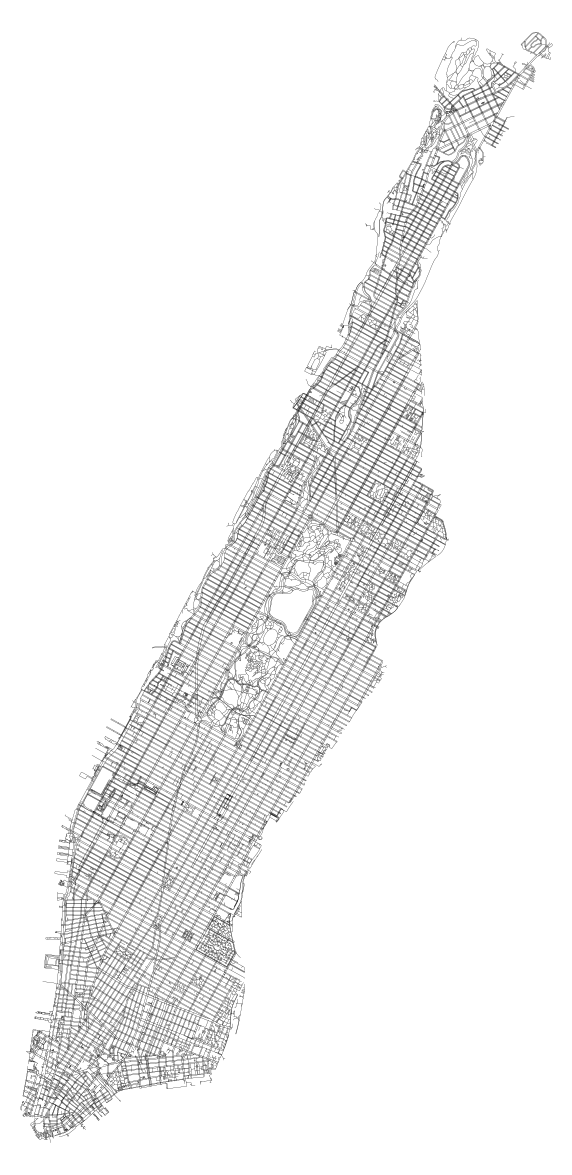

(<Figure size 1500x1500 with 1 Axes>, <Axes: >)

In [258]:
place = "Manhattan, New York, USA"
A = ox.graph.graph_from_place(place, network_type = "walk")
fig, ax = plt.subplots(figsize = (15,15))
ox.plot.plot_graph(A, bgcolor = "white", node_color = "black", edge_color = "black", node_size = 0, edge_linewidth = 0.1, ax=ax)

## Comment:defines Manhattan as the study area,
## downloads the walkable street network,
## plots the network for a quick visual check.

In [259]:
gdf_nodes, gdf_edges = ox.convert.graph_to_gdfs(A)
gdf_nodes.head()

,y,x,street_count,highway,ref,railway,geometry
osmid,,,,,,,
30807314,40.790720,-73.963576,4,NaN,NaN,NaN,POINT (-73.96358 40.79072)
30978747,40.774267,-73.973425,4,NaN,NaN,NaN,POINT (-73.97342 40.77427)
30978752,40.774769,-73.974393,4,NaN,NaN,NaN,POINT (-73.97439 40.77477)
42421731,40.798654,-73.961474,3,traffic_signals,NaN,NaN,POINT (-73.96147 40.79865)
42421737,40.799244,-73.962873,4,traffic_signals,NaN,NaN,POINT (-73.96287 40.79924)


In [260]:
gdf_edges['speed_kph'] = 5
A = ox.convert.graph_from_gdfs(gdf_nodes, gdf_edges)
A = ox.routing.add_edge_travel_times(A)

## Comment:Set walking speed to 5km/h.
## Then added travel times based on the walking speed.

In [261]:
tract_nodes = ox.distance.nearest_nodes(A, ny_df_tracts['x'], ny_df_tracts['y'])
tract_nodes = list(tract_nodes)
ny_df_tracts["nearest_nodes"] = tract_nodes
ny_df_tracts.head()

## Comment:Identify all the nodes thar are closest to the tract centroids, and made them into a list.
## Then added them into our ny_df_tracts DataFrame.

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,nearest_nodes
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,S,204327,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,9897810856
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,S,174218,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,8732555179
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,S,196979,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,2329911477
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,S,199278,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,6254630515
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,S,180003,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,42421803


<Axes: >

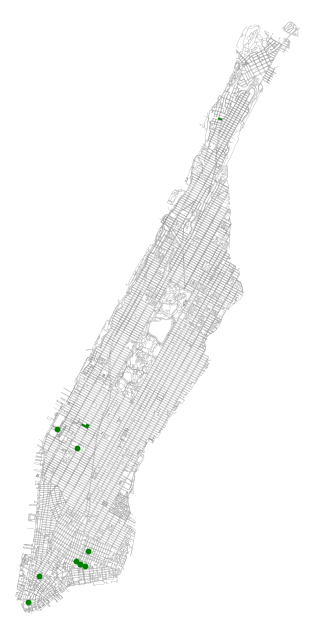

In [262]:
tags_busregional = {'amenity' : 'bus_station'}
gdf_busregional = ox.features.features_from_place(place, tags_busregional)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_busregional.plot(ax=ax, color='green', markersize=10)

## Comment:defines the OSM tag for regional bus stations,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

In [263]:
gdf_busregional

geometry  \
element id                                                               
node    2554956151                          POINT (-73.99084 40.71959)   
        2567558455                          POINT (-73.99402 40.71566)   
        2902930629                          POINT (-74.00289 40.75607)   
        5028831921                          POINT (-73.99204 40.71506)   
        5093187022                          POINT (-74.01442 40.70405)   
        6458076485                          POINT (-74.00987 40.71209)   
        6867960885                          POINT (-73.99509 40.75029)   
        6910663883                          POINT (-73.99548 40.71635)   
        10683893736                         POINT (-73.99371 40.71557)   
way     108160358    POLYGON ((-73.99083 40.75609, -73.99338 40.757...   
        275061119    POLYGON ((-73.93779 40.84848, -73.93905 40.848...   

                    addr:city addr:housenumber addr:postcode addr:state  \
element id                                                                
node    2554956151   New York               62         10002         NY   
        2567558455        NaN              103         10002        NaN   
        2902930629   New York              NaN         10001         NY   
        5028831921        NaN              NaN           NaN        NaN   
        5093187022        NaN              NaN           NaN        NaN   
        6458076485        NaN              NaN           NaN        NaN   
        6867960885        NaN              NaN           NaN        NaN   
        6910663883        NaN              145           NaN        NaN   
        10683893736       NaN               95           NaN        NaN   
way     108160358    New York              625           NaN         NY   
        275061119    New York              NaN           NaN         NY   

                          addr:street      amenity  bus  \
element id                                                
node    2554956151    Delancey Street  bus_station  yes   
        2567558455       Canal Street  bus_station  yes   
        2902930629   West 34th Street  bus_station  yes   
        5028831921                NaN  bus_station  yes   
        5093187022                NaN  bus_station  yes   
        6458076485                NaN  bus_station  yes   
        6867960885                NaN  bus_station  yes   
        6910663883       Canal Street  bus_station  yes   
        10683893736      Canal Street  bus_station  yes   
way     108160358          8th Avenue  bus_station  yes   
        275061119                 NaN  bus_station  yes   

                                                     name            phone  \
element id                                                                   
node    2554956151                             D3 Busline  +1-646-210-8928   
        2567558455                            Wanda Coach  +1 917 717 4666   
        2902930629                                Megabus              NaN   
        5028831921                              Tiger Bus              NaN   
        5093187022                                    NaN              NaN   
        6458076485                             The Oculus              NaN   
        6867960885             FlixBus NYC 300 W 31st St.              NaN   
        6910663883                             Lucky Star  +1-617-269-5468   
        10683893736                           95 Bus Stop  +1 212-965-8880   
way     108160358             Port Authority Bus Terminal              NaN   
        275061119    George Washington Bridge Bus Station              NaN   

                     ... operator:wikidata short_name  start_date toilets  \
element id           ...                                                    
node    2554956151   ...               NaN        NaN         NaN     NaN   
        2567558455   ...               NaN        NaN         NaN     NaN   
        2902930629   ...        

In [264]:
gdf_busregional['centroid'] = gdf_busregional['geometry'].centroid
gdf_busregional['x'] = gdf_busregional['centroid'].x
gdf_busregional['y'] = gdf_busregional['centroid'].y
gdf_busregional.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15228\809056918.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_busregional['centroid'] = gdf_busregional['geometry'].centroid


geometry addr:city addr:housenumber  \
element id                                                                  
node    2554956151  POINT (-73.99084 40.71959)  New York               62   
        2567558455  POINT (-73.99402 40.71566)       NaN              103   
        2902930629  POINT (-74.00289 40.75607)  New York              NaN   
        5028831921  POINT (-73.99204 40.71506)       NaN              NaN   
        5093187022  POINT (-74.01442 40.70405)       NaN              NaN   

                   addr:postcode addr:state       addr:street      amenity  \
element id                                                                   
node    2554956151         10002         NY   Delancey Street  bus_station   
        2567558455         10002        NaN      Canal Street  bus_station   
        2902930629         10001         NY  West 34th Street  bus_station   
        5028831921           NaN        NaN               NaN  bus_station   
        5093187022           NaN        NaN               NaN  bus_station   

                    bus         name            phone  ... toilets  \
element id                                             ...           
node    2554956151  yes   D3 Busline  +1-646-210-8928  ...     NaN   
        2567558455  yes  Wanda Coach  +1 917 717 4666  ...     NaN   
        2902930629  yes      Megabus              NaN  ...     NaN   
        5028831921  yes    Tiger Bus              NaN  ...     NaN   
        5093187022  yes          NaN              NaN  ...     NaN   

                   toilets:fee wikidata wikimedia_commons wikipedia  \
element id                                                            
node    2554956151         NaN      NaN               NaN       NaN   
        2567558455         NaN      NaN               NaN       NaN   
        2902930629         NaN      NaN               NaN       NaN   
        5028831921         NaN      NaN               NaN       NaN   
        5093187022         NaN      NaN               NaN       NaN   

                   air_conditioning internet_access:ssid  \
element id                                                 
node    2554956151              NaN                  NaN   
        2567558455              NaN                  NaN   
        2902930629              NaN                  NaN   
        5028831921              NaN                  NaN   
        5093187022              NaN                  NaN   

                                      centroid          x          y  
element id                                                            
node    2554956151  POINT (-73.99084 40.71959) -73.990836  40.719586  
        2567558455  POINT (-73.99402 40.71566) -73.994023  40.715662  
        2902930629  POINT (-74.00289 40.75607) -74.002890  40.756073  
        5028831921  POINT (-73.99204 40.71506) -73.992039  40.715063  
        5093187022  POINT (-74.01442 40.70405) -74.014416  40.704055  

[5 rows x 49 columns]

In [265]:
busregional_nodes = ox.distance.nearest_nodes(A, gdf_busregional['x'], gdf_busregional['y'])
busregional_nodes = list(busregional_nodes)
busregional_nodes
## Comment:Identify all the nodes thar are closest to the regional bus stops, and made them into a list.

[np.int64(8307642249),
 np.int64(4528918669),
 np.int64(593909360),
 np.int64(13068225207),
 np.int64(5037087617),
 np.int64(8262936509),
 np.int64(6814312333),
 np.int64(4528918665),
 np.int64(11826558566),
 np.int64(9201440708),
 np.int64(12925573366)]

In [266]:
nearest_time = nx.multi_source_dijkstra_path_length(A, busregional_nodes, weight = "travel_time")

## Comment:Get the nearest distance to the regional bus stop for every node in graph A.

In [267]:
tract_to_busregional = {a: nearest_time.get(a) for a in tract_nodes}
tract_to_busregional

## Comment:This is extracting only the nodes we identified that should be near the census tract centroids.

{np.int64(9897810856): 2396.3697849080804,
 np.int64(8732555179): 4323.187721761324,
 np.int64(2329911477): 2888.4369851910233,
 np.int64(6254630515): 4113.925076270941,
 np.int64(42421803): 2640.9543724701975,
 np.int64(4207779531): 4851.450102282958,
 np.int64(2329911577): 2948.101960029138,
 np.int64(7779608818): 4687.387382807042,
 np.int64(42438043): 2880.448084315657,
 np.int64(6256723782): 4467.182883791813,
 np.int64(7803460155): 4649.156570462613,
 np.int64(2967753947): 3138.5672771400923,
 np.int64(3875114028): 3115.6673009107285,
 np.int64(7925259044): 5465.211376447689,
 np.int64(2329911741): 3485.2583558427523,
 np.int64(7924346731): 5160.575830355023,
 np.int64(8687882783): 3327.8309298211225,
 np.int64(10122953002): 4768.217790726751,
 np.int64(2329798594): 3699.9326133428744,
 np.int64(10167086797): 4551.686565059539,
 np.int64(4111310274): 3492.3409973194643,
 np.int64(6223478838): 4455.3908346108465,
 np.int64(1684212082): 4007.777525464012,
 np.int64(10170834282): 49

In [268]:
tract_to_busregional = pd.DataFrame(list(tract_to_busregional.items()))
tract_to_busregional.head()

## Comment:We then changed it into a DataFrame.

,0,1
0,9897810856,2396.369785
1,8732555179,4323.187722
2,2329911477,2888.436985
3,6254630515,4113.925076
4,42421803,2640.954372


In [269]:
tract_to_busregional = tract_to_busregional.rename(columns = {
                        0:"nearest_nodes", 
                        1:"travel_time"}
)
tract_to_busregional.sort_values(by="travel_time")

## Comment:Renamed the columns, and then sorted by travel time (in seconds)

,nearest_nodes,travel_time
134,11826558566,0.000000
135,12993686212,70.242681
221,247075502,141.816744
94,9566938931,164.708421
117,5816038508,188.921929
...,...,...
27,7927125723,4968.621268
23,10170834282,4995.140788
15,7924346731,5160.575830
79,371218803,5298.101629


In [270]:
tract_busregional = pd.merge(left=ny_df_tracts, right=tract_to_busregional, on='nearest_nodes', how='left')
tract_busregional["travel_minute_regional"] = tract_busregional["travel_time"] / 60
tract_busregional.head()

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,nearest_nodes,travel_time,travel_minute_regional
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,9897810856,2396.369785,39.939496
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,8732555179,4323.187722,72.053129
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,2329911477,2888.436985,48.140616
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,6254630515,4113.925076,68.565418
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,42421803,2640.954372,44.015906


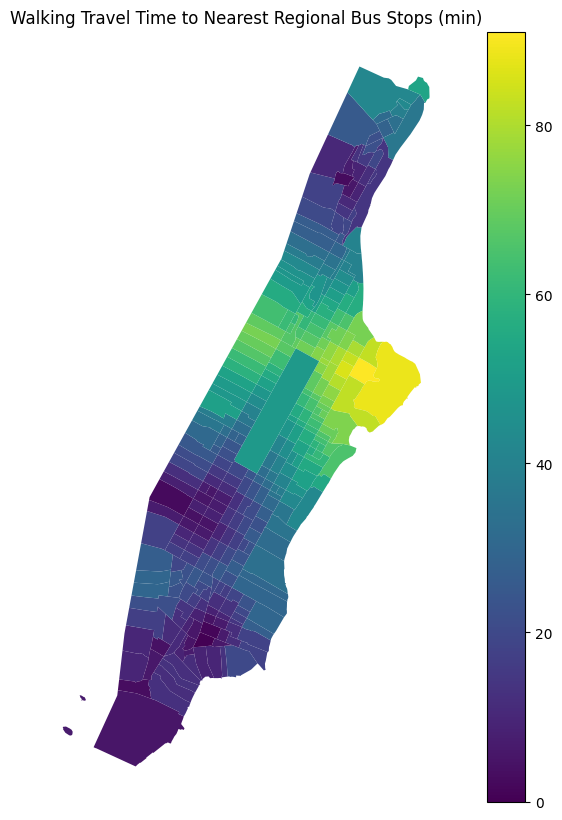

In [271]:
fig, ax = plt.subplots(figsize = (10,10))
tract_busregional.plot(ax=ax,column = 'travel_minute_regional', legend=True)
ax.set_title("Walking Travel Time to Nearest Regional Bus Stops (min)")
ax.set_axis_off()
plt.show()

<Axes: >

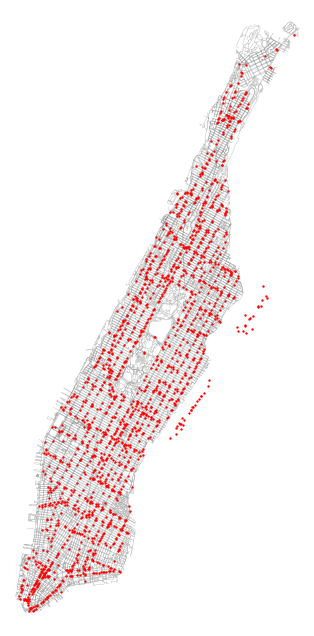

In [272]:
tags_buslocal = {'highway' : 'bus_stop'}
gdf_buslocal = ox.features.features_from_place(place, tags_buslocal)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_buslocal.plot(ax=ax, color='red', markersize=0.5)

## Comment:defines the OSM tag for local bus stations,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

In [273]:
gdf_buslocal['centroid'] = gdf_buslocal['geometry'].centroid
gdf_buslocal['x'] = gdf_buslocal['centroid'].x
gdf_buslocal['y'] = gdf_buslocal['centroid'].y
gdf_buslocal.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15228\1903203173.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_buslocal['centroid'] = gdf_buslocal['geometry'].centroid


geometry  bus   highway      local_ref  \
element id                                                                     
node    320949338   POINT (-73.95391 40.75742)  yes  bus_stop  Tram Bus Stop   
        419367181    POINT (-73.9776 40.74543)  yes  bus_stop            NaN   
        886414800   POINT (-73.99564 40.73058)  yes  bus_stop            NaN   
        1205714876  POINT (-73.93023 40.86183)  yes  bus_stop      M100, Bx7   
        1205714956  POINT (-73.93012 40.86308)  yes  bus_stop            NaN   

                                             name  \
element id                                          
node    320949338             Subway Station East   
        419367181   East 34th Street & 3rd Avenue   
        886414800                NYU Trolley Stop   
        1205714876      Broadway & Sherman Avenue   
        1205714956        Broadway & Dongan Place   

                                                  operator public_transport  \
element id                                                                    
node    320949338   Roosevelt Island Operating Corporation         platform   
        419367181                                      NaN         platform   
        886414800                                      NaN         platform   
        1205714876                                     NaN         platform   
        1205714956                                     NaN         platform   

                   shelter bench  bin  ... brand:wikidata description  \
element id                             ...                              
node    320949338       no   NaN  NaN  ...            NaN         NaN   
        419367181       no    no  NaN  ...            NaN         NaN   
        886414800       no    no   no  ...            NaN         NaN   
        1205714876      no   yes  yes  ...            NaN         NaN   
        1205714956     NaN   NaN  NaN  ...            NaN         NaN   

                   gtfs:route_id gtfs_stop_code network:short  \
element id                                                      
node    320949338            NaN            NaN           NaN   
        419367181            NaN            NaN           NaN   
        886414800            NaN            NaN           NaN   
        1205714876           NaN            NaN           NaN   
        1205714956           NaN            NaN           NaN   

                   departures_board:speech_output flickr  \
element id                                                 
node    320949338                             NaN    NaN   
        419367181                             NaN    NaN   
        886414800                             NaN    NaN   
        1205714876                            NaN    NaN   
        1205714956                            NaN    NaN   

                                      centroid          x          y  
element id                                                            
node    320949338   POINT (-73.95391 40.75742) -73.953914  40.757419  
        419367181    POINT (-73.9776 40.74543) -73.977595  40.745434  
        886414800   POINT (-73.99564 40.73058) -73.995642  40.730578  
        1205714876  POINT (-73.93023 40.86183) -73.930232  40.861828  
        1205714956  POINT (-73.93012 40.86308) -73.930124  40.863077  

[5 rows x 69 columns]

In [274]:
buslocal_nodes = ox.distance.nearest_nodes(A, gdf_buslocal['x'], gdf_buslocal['y'])
buslocal_nodes = list(buslocal_nodes)
buslocal_nodes

[np.int64(2348688853),
 np.int64(11552957036),
 np.int64(3584752268),
 np.int64(6882309082),
 np.int64(1205714997),
 np.int64(11594925628),
 np.int64(11594925594),
 np.int64(9561386480),
 np.int64(1209670337),
 np.int64(5120316944),
 np.int64(2348688853),
 np.int64(2348688853),
 np.int64(10165922627),
 np.int64(12673751232),
 np.int64(10166304815),
 np.int64(13342644335),
 np.int64(9987259798),
 np.int64(11454490715),
 np.int64(10171397830),
 np.int64(10171397826),
 np.int64(11655743699),
 np.int64(10170980697),
 np.int64(8431296949),
 np.int64(11236724401),
 np.int64(11657455865),
 np.int64(4284246582),
 np.int64(8709392071),
 np.int64(10170704054),
 np.int64(3686061916),
 np.int64(11587266246),
 np.int64(9561209004),
 np.int64(7706983360),
 np.int64(1251958138),
 np.int64(8304497422),
 np.int64(8709397325),
 np.int64(10198809058),
 np.int64(10166004114),
 np.int64(10261571156),
 np.int64(10169532568),
 np.int64(8307641606),
 np.int64(8376008903),
 np.int64(6927650852),
 np.int64(3248

In [275]:
nearest_time = nx.multi_source_dijkstra_path_length(A, buslocal_nodes, weight = "travel_time")
tract_to_buslocal = {a: nearest_time.get(a) for a in tract_nodes}
tract_to_buslocal

{np.int64(9897810856): 25.50597999114104,
 np.int64(8732555179): 0,
 np.int64(2329911477): 289.27202782088483,
 np.int64(6254630515): 66.99516676074106,
 np.int64(42421803): 13.575698910563835,
 np.int64(4207779531): 43.63273602487212,
 np.int64(2329911577): 348.93700265899923,
 np.int64(7779608818): 63.26723213520187,
 np.int64(42438043): 60.37353733517059,
 np.int64(6256723782): 40.80166052677635,
 np.int64(7803460155): 0,
 np.int64(2967753947): 66.461586723743,
 np.int64(3875114028): 18.633516848917317,
 np.int64(7925259044): 0,
 np.int64(2329911741): 285.80481817360067,
 np.int64(7924346731): 30.59694421362589,
 np.int64(8687882783): 0,
 np.int64(10122953002): 6.596109779296965,
 np.int64(2329798594): 85.7663537657354,
 np.int64(10167086797): 0,
 np.int64(4111310274): 87.05923713931516,
 np.int64(6223478838): 239.66858738548075,
 np.int64(1684212082): 338.64506580068985,
 np.int64(10170834282): 64.44938466901621,
 np.int64(9150552660): 79.43832275340355,
 np.int64(10168729751): 147

In [276]:
tract_to_buslocal = pd.DataFrame(list(tract_to_buslocal.items()))
tract_to_buslocal.head()

,0,1
0,9897810856,25.505980
1,8732555179,0.000000
2,2329911477,289.272028
3,6254630515,66.995167
4,42421803,13.575699


In [277]:
tract_to_buslocal = tract_to_buslocal.rename(columns = {
                        0:"nearest_nodes", 
                        1:"travel_time"}
)
tract_to_buslocal.sort_values(by="travel_time")

,nearest_nodes,travel_time
1,8732555179,0.000000
19,10167086797,0.000000
282,8782927417,0.000000
38,10165996963,0.000000
76,10165922627,0.000000
...,...,...
136,3236038864,487.887283
187,8288262779,588.796623
140,3236038904,635.665576
89,1721287304,877.978606


In [278]:
tract_buslocal = pd.merge(left=ny_df_tracts, right=tract_to_buslocal, on='nearest_nodes', how='left')
tract_buslocal["travel_minute_local"] = tract_buslocal["travel_time"] / 60
tract_buslocal.head()

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,nearest_nodes,travel_time,travel_minute_local
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,9897810856,25.505980,0.425100
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,8732555179,0.000000,0.000000
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,2329911477,289.272028,4.821200
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,6254630515,66.995167,1.116586
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,42421803,13.575699,0.226262


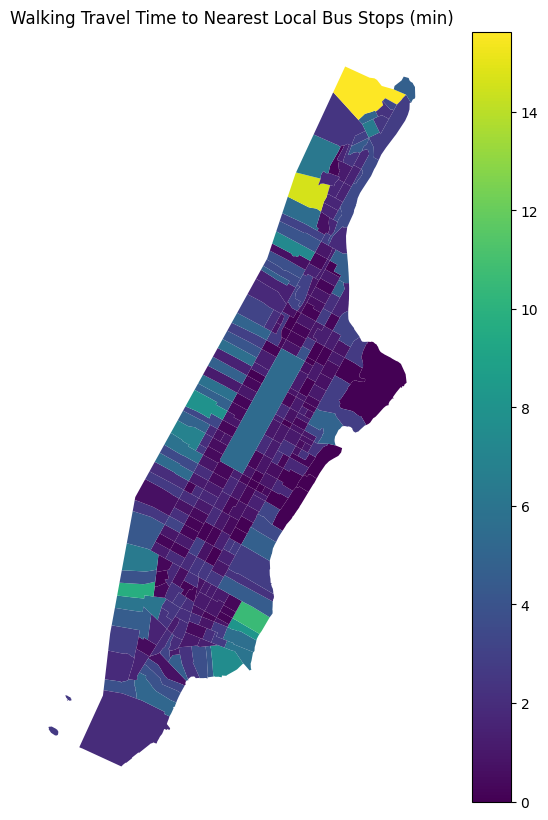

In [279]:
fig, ax = plt.subplots(figsize = (10,10))
tract_buslocal.plot(ax=ax,column = 'travel_minute_local', legend=True)
ax.set_title("Walking Travel Time to Nearest Local Bus Stops (min)")
ax.set_axis_off()
plt.show()

<Axes: >

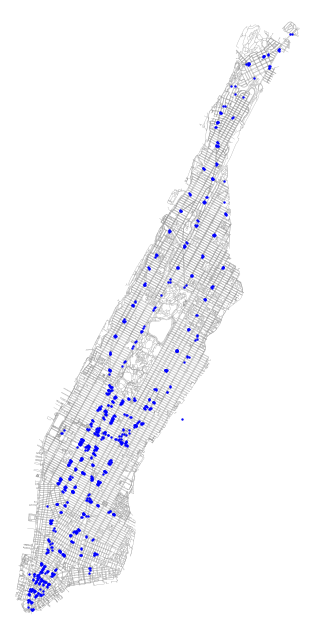

In [280]:
tags_subway = {'railway' : 'subway_entrance'}
gdf_subway = ox.features.features_from_place(place, tags_subway)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_subway.plot(ax=ax, color='blue', markersize = 0.5)

## Comment:defines the OSM tag for subway stations,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

In [281]:
gdf_subway['centroid'] = gdf_subway['geometry'].centroid
gdf_subway['x'] = gdf_subway['centroid'].x
gdf_subway['y'] = gdf_subway['centroid'].y
gdf_subway.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15228\3005250192.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_subway['centroid'] = gdf_subway['geometry'].centroid


geometry         description level  \
element id                                                                
node    348548369  POINT (-73.97798 40.76347)    all F,<F> trains     0   
        348548387  POINT (-73.97773 40.76338)    all F,<F> trains     0   
        401505767  POINT (-74.00266 40.73997)  all A,C,E,L trains     0   
        402612886  POINT (-74.00274 40.73995)  all A,C,E,L trains  -1;0   
        402613531  POINT (-74.00281 40.73974)  all A,C,E,L trains     0   

                           railway wheelchair  \
element id                                      
node    348548369  subway_entrance         no   
        348548387  subway_entrance         no   
        401505767  subway_entrance         no   
        402612886  subway_entrance        yes   
        402613531  subway_entrance         no   

                                                           name   highway  \
element id                                                                  
node    348548369  6th Avenue & 56th Street at Southwest Corner       NaN   
        348548387  6th Avenue & 56th Street at Southeast Corner       NaN   
        401505767                                           NaN       NaN   
        402612886                                           NaN  elevator   
        402613531                                           NaN       NaN   

                  check_date:wheelchair entrance wikidata  ...  ref fixme  \
element id                                                 ...              
node    348548369                   NaN      NaN      NaN  ...  NaN   NaN   
        348548387                   NaN      NaN      NaN  ...  NaN   NaN   
        401505767                   NaN      NaN      NaN  ...  NaN   NaN   
        402612886                   NaN      NaN      NaN  ...  NaN   NaN   
        402613531                   NaN      NaN      NaN  ...  NaN   NaN   

                  addr:city addr:postcode addr:state addr:street name:ko  \
element id                                                                 
node    348548369       NaN           NaN        NaN         NaN     NaN   
        348548387       NaN           NaN        NaN         NaN     NaN   
        401505767       NaN           NaN        NaN         NaN     NaN   
        402612886       NaN           NaN        NaN         NaN     NaN   
        402613531       NaN           NaN        NaN         NaN     NaN   

                                     centroid          x          y  
element id                                                           
node    348548369  POINT (-73.97798 40.76347) -73.977978  40.763471  
        348548387  POINT (-73.97773 40.76338) -73.977728  40.763378  
        401505767  POINT (-74.00266 40.73997) -74.002661  40.739966  
        402612886  POINT (-74.00274 40.73995) -74.002739  40.739952  
        402613531  POINT (-74.00281 40.73974) -74.002811  40.739744  

[5 rows x 34 columns]

In [282]:
subway_nodes = ox.distance.nearest_nodes(A, gdf_subway['x'], gdf_subway['y'])
subway_nodes = list(subway_nodes)
subway_nodes

[np.int64(10171655532),
 np.int64(10171655535),
 np.int64(8262308713),
 np.int64(8262308713),
 np.int64(8310246331),
 np.int64(8310246330),
 np.int64(8262308763),
 np.int64(494509181),
 np.int64(494509182),
 np.int64(10168207106),
 np.int64(597981952),
 np.int64(597981954),
 np.int64(597981960),
 np.int64(597981962),
 np.int64(8307641789),
 np.int64(597981975),
 np.int64(597981978),
 np.int64(8310246632),
 np.int64(11595000908),
 np.int64(11595000895),
 np.int64(11660936450),
 np.int64(8660596943),
 np.int64(1272674972),
 np.int64(8660596939),
 np.int64(1279255043),
 np.int64(1279255045),
 np.int64(1279255047),
 np.int64(1279255048),
 np.int64(1279312396),
 np.int64(1279312411),
 np.int64(1279337143),
 np.int64(1279337155),
 np.int64(7580792263),
 np.int64(1280340171),
 np.int64(1280340172),
 np.int64(1280340175),
 np.int64(1280340190),
 np.int64(1280340205),
 np.int64(1280366089),
 np.int64(1280366096),
 np.int64(10172901906),
 np.int64(10166333084),
 np.int64(1288901368),
 np.int64(1

In [283]:
nearest_time = nx.multi_source_dijkstra_path_length(A, subway_nodes, weight = "travel_time")
tract_to_subway = {a: nearest_time.get(a) for a in tract_nodes}
tract_to_subway

{np.int64(9897810856): 225.99921774781592,
 np.int64(8732555179): 84.12288721393205,
 np.int64(2329911477): 451.4679899184286,
 np.int64(6254630515): 270.55880688541754,
 np.int64(42421803): 299.1135449437551,
 np.int64(4207779531): 480.797847987932,
 np.int64(2329911577): 511.132964756543,
 np.int64(7779608818): 110.5179195339403,
 np.int64(42438043): 192.95014150246988,
 np.int64(6256723782): 321.0203245998984,
 np.int64(7803460155): 266.86384862380766,
 np.int64(2967753947): 326.3941054367822,
 np.int64(3875114028): 336.5854000842825,
 np.int64(7925259044): 705.3714128590359,
 np.int64(2329911741): 522.2285086367003,
 np.int64(7924346731): 373.6488316043411,
 np.int64(8687882783): 179.89506612153434,
 np.int64(10122953002): 6.596109779296965,
 np.int64(2329798594): 344.1993154277132,
 np.int64(10167086797): 209.93511588791534,
 np.int64(4111310274): 271.1996449920222,
 np.int64(6223478838): 183.5423316052242,
 np.int64(1684212082): 564.9815090873105,
 np.int64(10170834282): 315.9872

In [284]:
tract_to_subway = pd.DataFrame(list(tract_to_subway.items()))
tract_to_subway.head()

,0,1
0,9897810856,225.999218
1,8732555179,84.122887
2,2329911477,451.467990
3,6254630515,270.558807
4,42421803,299.113545


In [285]:
tract_to_subway = tract_to_subway.rename(columns = {
                        0:"nearest_nodes", 
                        1:"travel_time"}
)
tract_to_subway.sort_values(by="travel_time")

,nearest_nodes,travel_time
67,11218080012,0.000000
270,13038742244,0.000000
222,10173080167,0.000000
175,8309479147,0.000000
223,9414480622,1.471333
...,...,...
265,7573140375,989.561472
120,8313261673,1023.898369
256,10864461089,1148.383436
136,3236038864,1314.278801


In [286]:
tract_subway = pd.merge(left=ny_df_tracts, right=tract_to_subway, on='nearest_nodes', how='left')
tract_subway["travel_minute_subway"] = tract_subway["travel_time"] / 60
tract_subway.head()

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,nearest_nodes,travel_time,travel_minute_subway
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,9897810856,225.999218,3.766654
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,8732555179,84.122887,1.402048
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,2329911477,451.467990,7.524466
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,6254630515,270.558807,4.509313
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,42421803,299.113545,4.985226


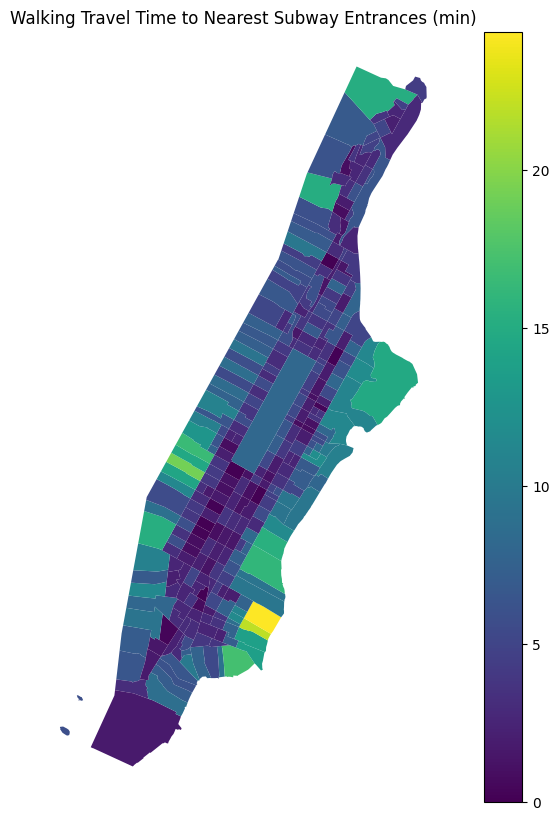

In [287]:
fig, ax = plt.subplots(figsize = (10,10))
tract_subway.plot(ax=ax,column = 'travel_minute_subway', legend=True)
ax.set_title("Walking Travel Time to Nearest Subway Entrances (min)")
ax.set_axis_off()
plt.show()

<Axes: >

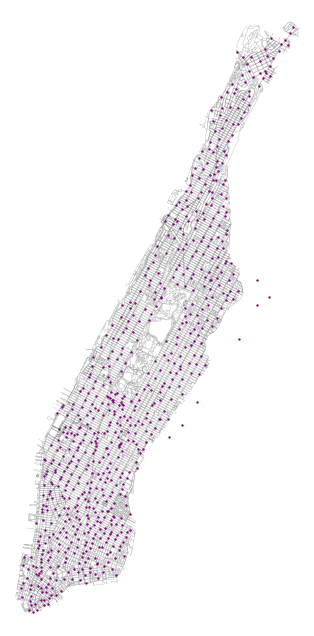

In [288]:
tags_bicycle = {'amenity' : 'bicycle_rental'}
gdf_bicycle = ox.features.features_from_place(place, tags_bicycle)
fig, ax = ox.plot.plot_graph(A, bgcolor = "white", node_size = 0, edge_linewidth = 0.1, show=False)
gdf_bicycle.plot(ax=ax, color='purple', markersize=0.5)

## Comment:defines the OSM tag for bicycle rents points,
##  downloads the corresponding point features for Manhattan,
##  plots them on top of the walking network for a quick check.

In [289]:
gdf_bicycle['centroid'] = gdf_bicycle['geometry'].centroid
gdf_bicycle['x'] = gdf_bicycle['centroid'].x
gdf_bicycle['y'] = gdf_bicycle['centroid'].y
gdf_bicycle.head()

C:\Users\Admin\AppData\Local\Temp\ipykernel_15228\4100365384.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf_bicycle['centroid'] = gdf_bicycle['geometry'].centroid


geometry         amenity  \
element id                                                       
node    419360569   POINT (-73.98298 40.75033)  bicycle_rental   
        419364457   POINT (-73.99188 40.75451)  bicycle_rental   
        419366395    POINT (-73.97672 40.7852)  bicycle_rental   
        1383944731  POINT (-73.97985 40.76645)  bicycle_rental   
        2337585114  POINT (-73.98142 40.72741)  bicycle_rental   

                     bicycle_rental      brand brand:wikidata capacity  \
element id                                                               
node    419360569   docking_station  Citi Bike       Q2974438        2   
        419364457   docking_station  Citi Bike       Q2974438       65   
        419366395   docking_station  Citi Bike       Q2974438       39   
        1383944731             shop        NaN            NaN      NaN   
        2337585114  docking_station  Citi Bike       Q2974438      107   

                   cityracks.housenum cityracks.installed cityracks.large  \
element id                                                                  
node    419360569                 411            4/5/2000               0   
        419364457                 555                 NaN               0   
        419366395                 NaN                 NaN             NaN   
        1383944731                NaN                 NaN             NaN   
        2337585114                NaN                 NaN             NaN   

                   cityracks.rackid  ... payment:notes  \
element id                           ...                 
node    419360569              1575  ...           NaN   
        419364457              1286  ...           NaN   
        419366395               NaN  ...           NaN   
        1383944731              NaN  ...           NaN   
        2337585114              NaN  ...           NaN   

                   payment:telephone_cards internet_access building height  \
element id                                                                   
node    419360569                      NaN             NaN      NaN    NaN   
        419364457                      NaN             NaN      NaN    NaN   
        419366395                      NaN             NaN      NaN    NaN   
        1383944731                     NaN             NaN      NaN    NaN   
        2337585114                     NaN             NaN      NaN    NaN   

                   nycdoitt:bin payment:contactless  \
element id                                            
node    419360569           NaN                 NaN   
        419364457           NaN                 NaN   
        419366395           NaN                 NaN   
        1383944731          NaN                 NaN   
        2337585114          NaN                 NaN   

                                      centroid          x          y  
element id                                                            
node    419360569   POINT (-73.98298 40.75033) -73.982979  40.750333  
        419364457   POINT (-73.99188 40.75451) -73.991879  40.754510  
        419366395    POINT (-73.97672 40.7852) -73.976722  40.785204  
        1383944731  POINT (-73.97985 40.76645) -73.979847  40.766447  
        2337585114  POINT (-73.98142 40.72741) -73.981420  40.727408  

[5 rows x 61 columns]

In [290]:
bicycle_nodes = ox.distance.nearest_nodes(A, gdf_bicycle['x'], gdf_bicycle['y'])
bicycle_nodes = list(bicycle_nodes)
bicycle_nodes

[np.int64(10166333023),
 np.int64(10168381337),
 np.int64(11655743693),
 np.int64(13038742231),
 np.int64(8310246149),
 np.int64(8309479239),
 np.int64(4216045812),
 np.int64(5854381577),
 np.int64(7579123486),
 np.int64(11608958690),
 np.int64(8119462489),
 np.int64(12394019801),
 np.int64(10171655533),
 np.int64(8307463485),
 np.int64(8262308732),
 np.int64(10166521626),
 np.int64(6751794456),
 np.int64(11016696147),
 np.int64(8119462444),
 np.int64(10311946143),
 np.int64(7465116043),
 np.int64(4011424285),
 np.int64(5035490159),
 np.int64(7138157372),
 np.int64(7465102441),
 np.int64(10171337709),
 np.int64(4298757034),
 np.int64(4298757017),
 np.int64(6716668062),
 np.int64(8261123022),
 np.int64(5542715084),
 np.int64(12148509063),
 np.int64(12517196208),
 np.int64(10263177586),
 np.int64(9419131206),
 np.int64(8660596998),
 np.int64(10073946218),
 np.int64(8310246371),
 np.int64(10168486333),
 np.int64(10168047577),
 np.int64(13031124391),
 np.int64(5863593971),
 np.int64(493138

In [291]:
nearest_time = nx.multi_source_dijkstra_path_length(A, bicycle_nodes, weight = "travel_time")
tract_to_bicycle = {a: nearest_time.get(a) for a in tract_nodes}
tract_to_bicycle

{np.int64(9897810856): 235.62973340697667,
 np.int64(8732555179): 94.17810959491445,
 np.int64(2329911477): 360.0911938487977,
 np.int64(6254630515): 95.79998369598768,
 np.int64(42421803): 9.474145171135357,
 np.int64(4207779531): 221.58783938580424,
 np.int64(2329911577): 254.74250629391037,
 np.int64(7779608818): 165.31521759694067,
 np.int64(42438043): 61.70477766180833,
 np.int64(6256723782): 122.92834880646794,
 np.int64(7803460155): 137.9458463728774,
 np.int64(2967753947): 233.6756142528487,
 np.int64(3875114028): 171.46377064794135,
 np.int64(7925259044): 118.45724094324434,
 np.int64(2329911741): 218.18894113005962,
 np.int64(7924346731): 166.36242008553637,
 np.int64(8687882783): 58.644260344509746,
 np.int64(10122953002): 65.44300733144297,
 np.int64(2329798594): 312.4675656840083,
 np.int64(10167086797): 88.28969873602153,
 np.int64(4111310274): 200.74179744552157,
 np.int64(6223478838): 174.64753440198865,
 np.int64(1684212082): 401.13491280864895,
 np.int64(10170834282):

In [292]:
tract_to_bicycle = pd.DataFrame(list(tract_to_bicycle.items()))
tract_to_bicycle.head()

,0,1
0,9897810856,235.629733
1,8732555179,94.178110
2,2329911477,360.091194
3,6254630515,95.799984
4,42421803,9.474145


In [293]:
tract_to_bicycle = tract_to_bicycle.rename(columns = {
                        0:"nearest_nodes", 
                        1:"travel_time"}
)
tract_to_bicycle.sort_values(by="travel_time")

,nearest_nodes,travel_time
306,371215829,0.000000
37,6001651081,0.000000
48,10171865591,0.000000
228,10168544044,0.000000
214,10166333106,0.000000
...,...,...
275,4290879363,453.643154
307,10160790880,549.436168
140,3236038904,591.248529
89,1721287304,696.481028


In [294]:
tract_bicycle = pd.merge(left=ny_df_tracts, right=tract_to_bicycle, on='nearest_nodes', how='left')
tract_bicycle["travel_minute_bicycle"] = tract_bicycle["travel_time"] / 60
tract_bicycle.head()

,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,AWATER,INTPTLAT,INTPTLON,geometry,centroid,x,y,nearest_nodes,travel_time,travel_minute_bicycle
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,0,+40.7823577,-073.9749988,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,9897810856,235.629733,3.927162
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,0,+40.7893731,-073.9483928,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,8732555179,94.178110,1.569635
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,142852,+40.7861484,-073.9838791,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,2329911477,360.091194,6.001520
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,0,+40.7910751,-073.9513565,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,6254630515,95.799984,1.596666
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,0,+40.7851959,-073.9731196,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,42421803,9.474145,0.157902


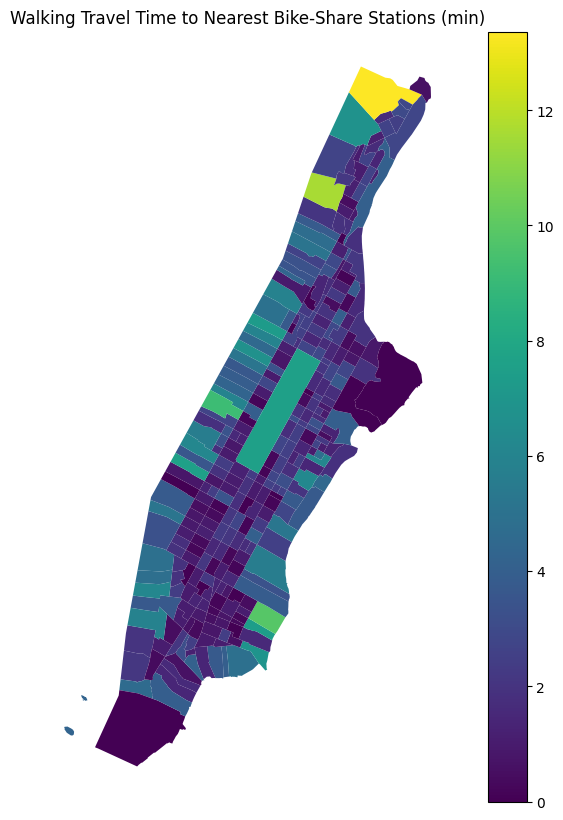

In [295]:
fig, ax = plt.subplots(figsize = (10,10))
tract_bicycle.plot(ax=ax,column = 'travel_minute_bicycle', legend=True)
ax.set_title("Walking Travel Time to Nearest Bike-Share Stations (min)")
ax.set_axis_off()
plt.show()

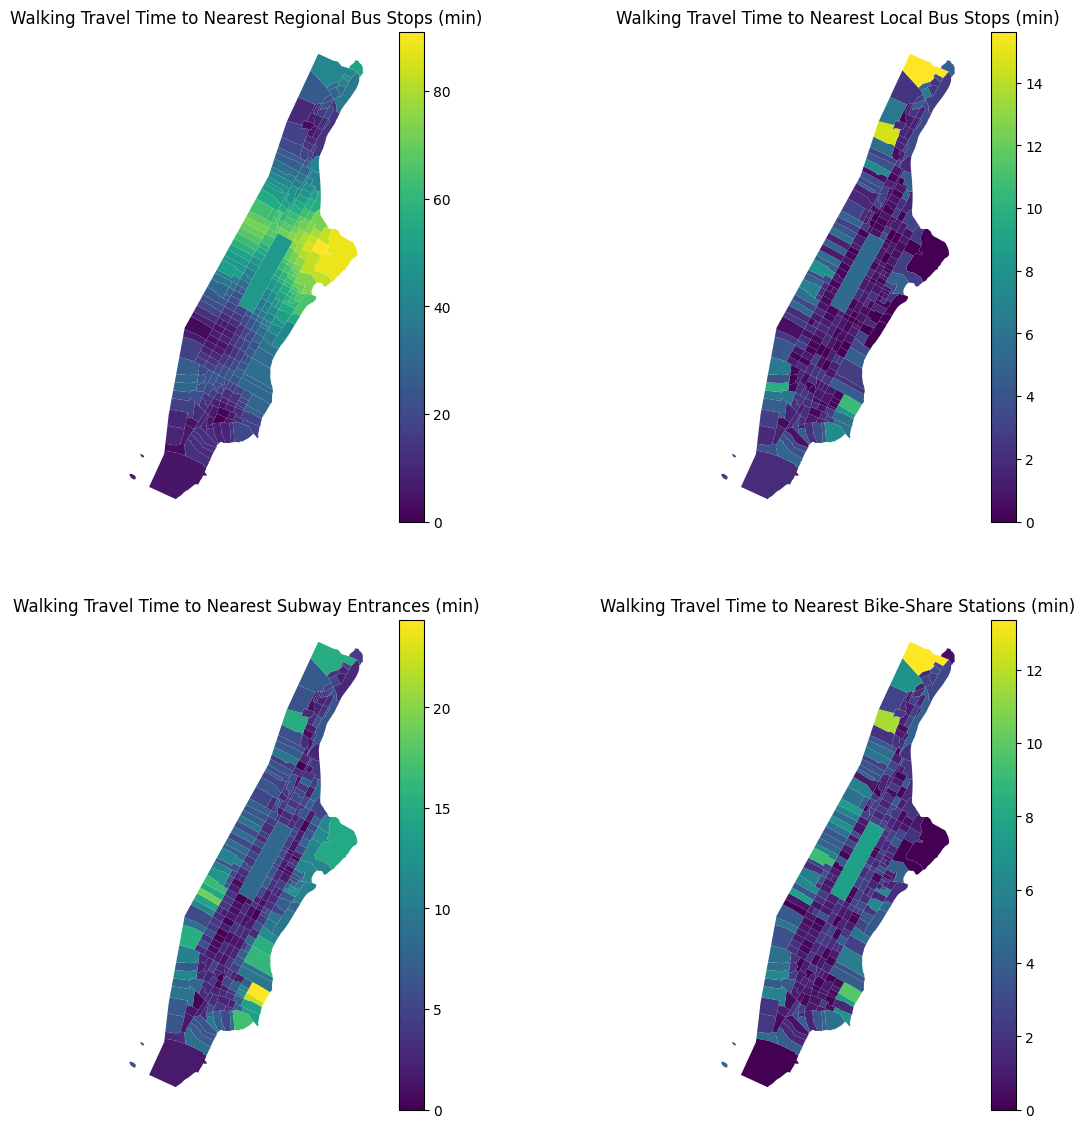

In [296]:
fig, axes = plt.subplots(2, 2, figsize = (14,14))

tract_busregional.plot(ax=axes[0,0],column = 'travel_minute_regional', legend=True)
axes[0,0].set_title("Walking Travel Time to Nearest Regional Bus Stops (min)")
axes[0,0].set_axis_off()

tract_buslocal.plot(ax=axes[0,1],column = 'travel_minute_local', legend=True)
axes[0,1].set_title("Walking Travel Time to Nearest Local Bus Stops (min)")
axes[0,1].set_axis_off()

tract_subway.plot(ax=axes[1,0],column = 'travel_minute_subway', legend=True)
axes[1,0].set_title("Walking Travel Time to Nearest Subway Entrances (min)")
axes[1,0].set_axis_off()

tract_bicycle.plot(ax=axes[1,1],column = 'travel_minute_bicycle', legend=True)
axes[1,1].set_title("Walking Travel Time to Nearest Bike-Share Stations (min)")
axes[1,1].set_axis_off()
plt.show()

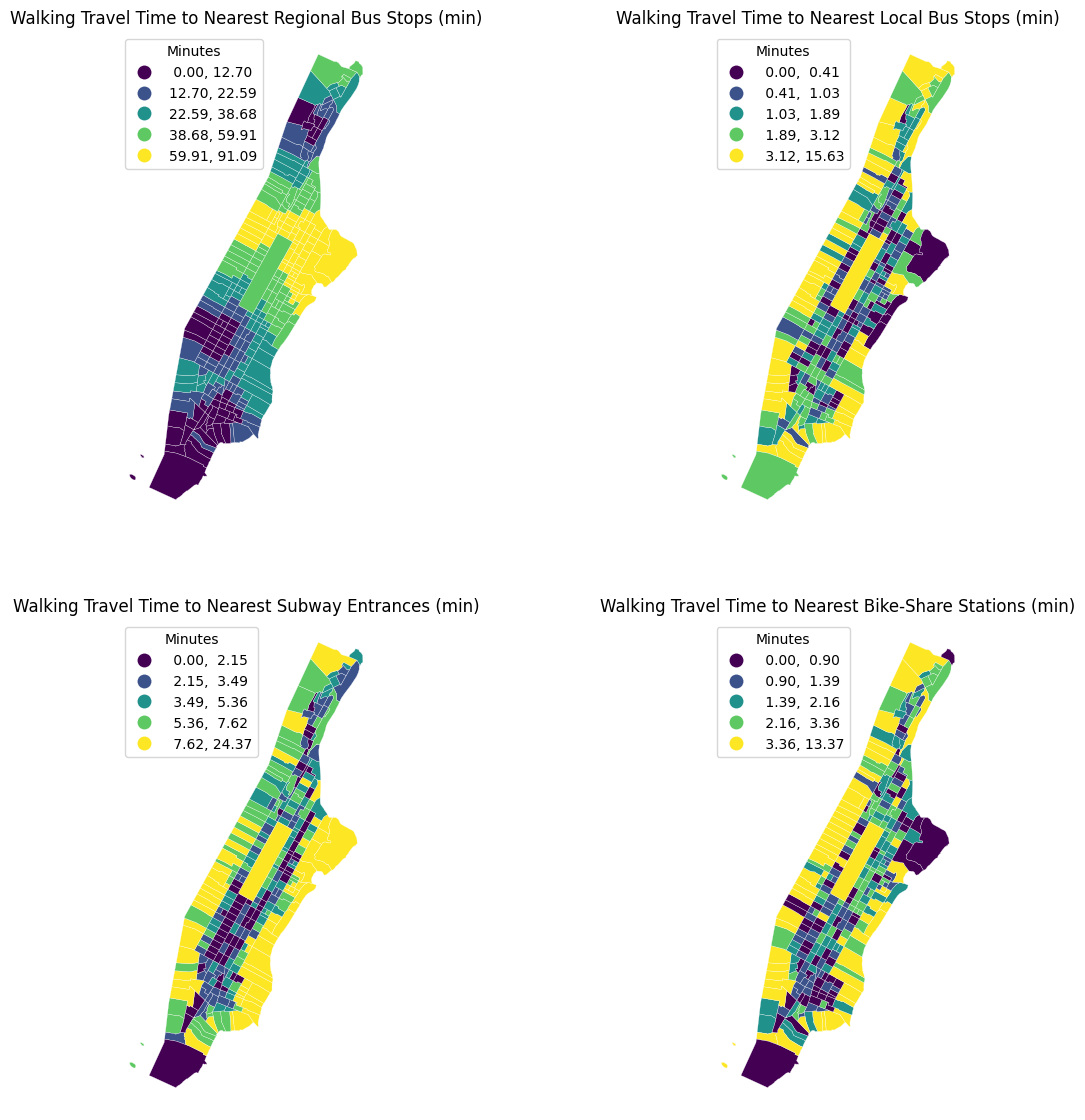

In [297]:
fig, axes = plt.subplots(2, 2, figsize = (14,14))

tract_busregional.plot(ax=axes[0,0], column = 'travel_minute_regional', edgecolor = 'white', linewidth = 0.2, scheme = 'Quantiles', k=5, legend=True,
                      legend_kwds = {
                          'loc' : 'upper left',
                          'title' : 'Minutes'
                      })
axes[0,0].set_title("Walking Travel Time to Nearest Regional Bus Stops (min)")
axes[0,0].set_axis_off()

tract_buslocal.plot(ax=axes[0,1], column = 'travel_minute_local', edgecolor = 'white', linewidth = 0.2, scheme = 'Quantiles', k=5, legend=True,
                      legend_kwds = {
                          'loc' : 'upper left',
                          'title' : 'Minutes'
                      })
axes[0,1].set_title("Walking Travel Time to Nearest Local Bus Stops (min)")
axes[0,1].set_axis_off()

tract_subway.plot(ax=axes[1,0], column = 'travel_minute_subway', edgecolor = 'white', linewidth = 0.2, scheme = 'Quantiles', k=5, legend=True,
                      legend_kwds = {
                          'loc' : 'upper left',
                          'title' : 'Minutes'
                      })
axes[1,0].set_title("Walking Travel Time to Nearest Subway Entrances (min)")
axes[1,0].set_axis_off()

tract_bicycle.plot(ax=axes[1,1], column = 'travel_minute_bicycle', edgecolor = 'white', linewidth = 0.2, scheme = 'Quantiles', k=5, legend=True,
                      legend_kwds = {
                          'loc' : 'upper left',
                          'title' : 'Minutes'
                      })
axes[1,1].set_title("Walking Travel Time to Nearest Bike-Share Stations (min)")
axes[1,1].set_axis_off()
plt.show()

In [298]:
tract_mobility = tract_busregional.copy()

tract_mobility = tract_mobility.rename(columns = {'travel_minute_regional':'busregional'})
tract_mobility['buslocal'] = tract_buslocal['travel_minute_local']
tract_mobility['subway'] = tract_subway['travel_minute_subway']
tract_mobility['bicycle'] = tract_bicycle['travel_minute_bicycle']
print(tract_mobility.columns)
tract_mobility.head()

Index(['Total Population', 'Per Capita Income', 'White Population',
       'Population Measured for Poverty Status', 'People Below Poverty Level',
       'Occupied_units', 'state', 'county', 'tract', 'GEOID', 'white_share',
       'nonwhite_share', 'poverty_rate', 'STATEFP', 'COUNTYFP', 'TRACTCE',
       'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT',
       'INTPTLON', 'geometry', 'centroid', 'x', 'y', 'nearest_nodes',
       'travel_time', 'busregional', 'buslocal', 'subway', 'bicycle'],
      dtype='str')


,Total Population,Per Capita Income,White Population,Population Measured for Poverty Status,People Below Poverty Level,Occupied_units,state,county,tract,GEOID,...,geometry,centroid,x,y,nearest_nodes,travel_time,busregional,buslocal,subway,bicycle
0,6674.0,167016.0,5425.0,6674.0,630.0,3176.0,36,061,016500,36061016500,...,"POLYGON ((-73.97859 40.78278, -73.97833 40.783...",POINT (-73.975 40.78236),-73.974999,40.782358,9897810856,2396.369785,39.939496,0.425100,3.766654,3.927162
1,6002.0,33090.0,2824.0,5915.0,1790.0,2796.0,36,061,016600,36061016600,...,"POLYGON ((-73.95118 40.7885, -73.95071 40.7891...",POINT (-73.94839 40.78937),-73.948393,40.789373,8732555179,4323.187722,72.053129,0.000000,1.402048,1.569635
2,6058.0,146433.0,5236.0,6058.0,559.0,2969.0,36,061,016700,36061016700,...,"POLYGON ((-73.99001 40.79044, -73.98988 40.790...",POINT (-73.98372 40.78647),-73.983717,40.786469,2329911477,2888.436985,48.140616,4.821200,7.524466,6.001520
3,5189.0,40997.0,1721.0,4596.0,1992.0,1774.0,36,061,016800,36061016800,...,"POLYGON ((-73.95456 40.78955, -73.95389 40.790...",POINT (-73.95136 40.79108),-73.951356,40.791075,6254630515,4113.925076,68.565418,1.116586,4.509313,1.596666
4,8272.0,110684.0,6895.0,8196.0,859.0,3949.0,36,061,016900,36061016900,...,"POLYGON ((-73.97644 40.78573, -73.97598 40.786...",POINT (-73.97312 40.7852),-73.973120,40.785196,42421803,2640.954372,44.015906,0.226262,4.985226,0.157902


In [299]:
lm = smf.ols(formula='busregional ~ white_share + poverty_rate + occupied_units', data=tract_mobility).fit()


PatsyError: Error evaluating factor: NameError: name 'occupied_units' is not defined
    busregional ~ white_share + poverty_rate + occupied_units
                                               ^^^^^^^^^^^^^^